In [59]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/diamonds.csv")

In [60]:
df

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [29]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [30]:
df.describe(include = 'object')

,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


In [31]:
df = df.drop('Unnamed: 0', axis = 1)

<Axes: >

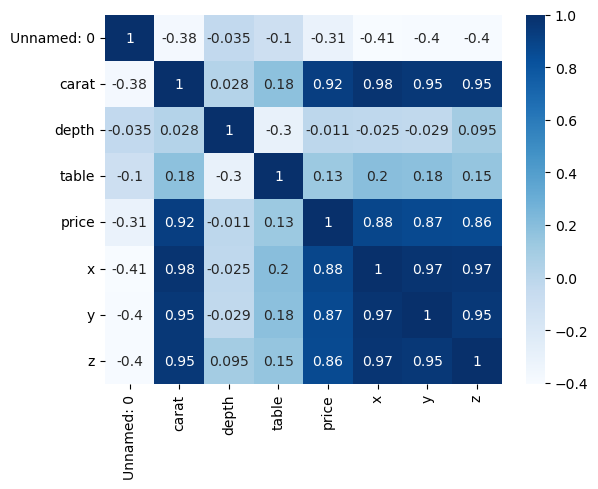

In [61]:
import seaborn as sns
corr = df.corr(numeric_only = True)
sns.heatmap(corr, cmap = 'Blues', annot = True)

In [33]:
corr

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


In [34]:
df = pd.get_dummies(df, columns = ['cut' , 'color', 'clarity'], drop_first = True)

In [35]:
df

,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,True,False,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,False,True,False,...,False,False,False,False,True,False,False,False,False,False
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,True,False,False,...,False,False,False,False,True,False,False,False,False,False
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,False,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,False,False,True,...,True,False,False,False,False,True,False,False,False,False


In [36]:
X = df.drop('price', axis = 1)
y = df['price']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [38]:
# Масштабирование датасета
from sklearn.preprocessing import StandardScaler 
model = StandardScaler()
model.fit(X_train)
X_train_scaled = model.transform(X_train)
X_test_scaled = model.transform(X_test)

In [42]:
X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

In [41]:
X_train_scaled

,carat,depth,table,x,y,z,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
19497,0.862659,-0.311437,-0.207099,1.055581,0.986556,0.968253,-0.314881,1.227398,-0.585893,-0.539653,...,2.329335,-0.333294,-0.234494,-0.184885,-0.568277,-0.451216,-0.422668,-0.542475,-0.270252,3.121212
31229,-1.029889,0.178549,-0.656213,-1.207734,-1.202544,-1.168276,-0.314881,1.227398,-0.585893,-0.539653,...,-0.429307,-0.333294,-0.234494,-0.184885,-0.568277,-0.451216,-0.422668,1.843403,-0.270252,-0.320388
22311,0.862659,0.458541,-0.207099,0.904099,0.951670,0.982309,-0.314881,1.227398,-0.585893,-0.539653,...,-0.429307,-0.333294,-0.234494,-0.184885,-0.568277,-0.451216,2.365922,-0.542475,-0.270252,-0.320388
278,0.021527,0.598537,-1.105327,0.164512,0.192898,0.251391,-0.314881,1.227398,-0.585893,-0.539653,...,-0.429307,-0.333294,-0.234494,-0.184885,-0.568277,2.216235,-0.422668,-0.542475,-0.270252,-0.320388
6646,-0.020530,-0.031445,-0.656213,0.182333,0.184176,0.181110,-0.314881,1.227398,-0.585893,-0.539653,...,-0.429307,3.000353,-0.234494,-0.184885,-0.568277,-0.451216,-0.422668,-0.542475,-0.270252,3.121212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.526206,0.458541,0.691128,0.663511,0.672581,0.715243,-0.314881,-0.814732,-0.585893,1.853044,...,-0.429307,3.000353,-0.234494,-0.184885,-0.568277,-0.451216,-0.422668,1.843403,-0.270252,-0.320388
44732,-0.693436,-0.521432,-1.105327,-0.628540,-0.635646,-0.676312,-0.314881,1.227398,-0.585893,-0.539653,...,-0.429307,-0.333294,-0.234494,-0.184885,-0.568277,-0.451216,2.365922,-0.542475,-0.270252,-0.320388
38158,-0.987832,-1.011418,0.242014,-1.109717,-1.115329,-1.182333,-0.314881,-0.814732,-0.585893,1.853044,...,-0.429307,-0.333294,-0.234494,5.408771,-0.568277,-0.451216,-0.422668,-0.542475,-0.270252,-0.320388
860,0.210782,0.738533,0.691128,0.351636,0.253949,0.391952,-0.314881,-0.814732,1.706796,-0.539653,...,-0.429307,-0.333294,4.264502,-0.184885,1.759705,-0.451216,-0.422668,-0.542475,-0.270252,-0.320388


In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
model = LinearRegression()
model.fit(X_train_scaled, y_train)

prediction_test = model.predict(X_test_scaled)
prediction_train = model.predict(X_train_scaled)
R2_test = r2_score(y_true = y_test, y_pred = prediction_test)
R2_train = r2_score(y_true = y_train, y_pred = prediction_train)
print(R2_train, R2_test)

0.9195976267987521 0.9201866914388086


In [56]:
coefficients = model.coef_
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': coefficients
})
min_value = min(coef_df['coefficient'])

In [51]:
coef_df

,feature,coefficient
0,carat,5338.615671
1,depth,-90.173817
2,table,-60.332280
3,x,-1100.418850
4,y,-6.458917
5,z,-34.258945
6,cut_Good,170.602933
7,cut_Ideal,414.369515
8,cut_Premium,339.239204
9,cut_Very Good,310.654256
